# First Run This

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import numpy as np
import os
import time
import argparse
import joblib
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Create directories
if not os.path.exists('data'):
    os.makedirs('data')

if not os.path.exists('data/processed'):
    os.makedirs('data/processed')

if not os.path.exists('models/saved'):
    os.makedirs('models/saved')

print("Libraries imported and directories created.")

Libraries imported and directories created.


### after folders created
##### Download https://www.kaggle.com/datasets/elmahy/pems-dataset/data --> PEMS04 
##### Save PEMS04.csv and PEMS04.npz into data folder

In [2]:
class TemporalConvLayer(nn.Module):
    """
    Temporal Convolutional Layer with Gated Linear Unit (GLU).
    """
    def __init__(self, in_channels, out_channels, kernel_size=3):
        super(TemporalConvLayer, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels * 2, (1, kernel_size),
                              padding=(0, (kernel_size - 1) // 2))

    def forward(self, x):
        """
        Args:
            x (torch.Tensor): Input (batch, in_channels, num_nodes, seq_len)
        Returns:
            torch.Tensor: Output (batch, out_channels, num_nodes, seq_len)
        """
        x_conv = self.conv(x)
        P = x_conv[:, :x_conv.shape[1] // 2, :, :]
        Q = x_conv[:, x_conv.shape[1] // 2:, :, :]
        return torch.sigmoid(Q) * P

class SpatioConvLayer(nn.Module):
    """
    Spatial Graph Convolutional Layer.
    """
    def __init__(self, in_channels, out_channels):
        super(SpatioConvLayer, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, (1, 1))

    def forward(self, x, adj_matrix):
        """
        Args:
            x (torch.Tensor): Input (batch, in_channels, num_nodes, seq_len)
            adj_matrix (torch.Tensor): Normalized adj matrix (num_nodes, num_nodes)
        Returns:
            torch.Tensor: Output (batch, out_channels, num_nodes, seq_len)
        """
        x_gcn = torch.einsum('vv,ncvt->ncvt', adj_matrix, x)
        return F.relu(self.conv(x_gcn))

class STConvBlock(nn.Module):
    """
    Spatio-Temporal Convolutional Block
    """
    def __init__(self, in_channels, hidden_channels, out_channels, kernel_size=3):
        super(STConvBlock, self).__init__()
        self.temporal_conv1 = TemporalConvLayer(in_channels, hidden_channels, kernel_size)
        self.spatial_conv = SpatioConvLayer(hidden_channels, hidden_channels)
        self.temporal_conv2 = TemporalConvLayer(hidden_channels, out_channels, kernel_size)
        self.batch_norm = nn.BatchNorm2d(out_channels)
        self.residual = nn.Conv2d(in_channels, out_channels, (1, 1)) if in_channels != out_channels else nn.Identity()

    def forward(self, x, adj_matrix):
        res = self.residual(x)
        x = self.temporal_conv1(x)
        x = self.spatial_conv(x, adj_matrix)
        x = F.relu(x)
        x = self.temporal_conv2(x)
        x = x + res
        x = self.batch_norm(x)
        return x

class STGCN(nn.Module):
    """
    Spatio-Temporal Graph Convolutional Network (STGCN)
    """
    def __init__(self, num_nodes, in_features, seq_len, pred_len,
                 channels=[64, 16, 64], kernel_size=3):
        super(STGCN, self).__init__()
        self.num_nodes = num_nodes
        self.in_features = in_features
        self.seq_len = seq_len
        self.pred_len = pred_len

        self.input_conv = nn.Conv2d(in_features, channels[0], (1, 1))

        self.st_blocks = nn.ModuleList()
        self.st_blocks.append(
            STConvBlock(channels[0], channels[1], channels[2], kernel_size)
        )
        self.st_blocks.append(
            STConvBlock(channels[2], channels[1], channels[2], kernel_size)
        )

        self.final_temporal_conv = nn.Conv2d(seq_len, pred_len, (1, 1))
        self.final_feature_conv = nn.Conv2d(channels[2], in_features, (1, 1))

    def forward(self, x, adj_matrix):
        """
        Args:
            x (torch.Tensor): Input (batch, seq_len, num_nodes, in_features)
            adj_matrix (torch.Tensor): (num_nodes, num_nodes)
        Returns:
            torch.Tensor: Prediction (batch, pred_len, num_nodes, in_features)
        """
        x = x.permute(0, 3, 2, 1) # (b, f, n, t)
        x = self.input_conv(x)

        for block in self.st_blocks:
            x = block(x, adj_matrix)

        x = self.final_feature_conv(x) # (b, in_features, n, t)
        x = x.permute(0, 3, 2, 1) # (b, t, n, in_features)
        x = self.final_temporal_conv(x) # (b, pred_len, n, in_features)
        return x

print("STGCN model defined.")

STGCN model defined.


In [3]:
class SpatialAttention(nn.Module):
    """
    Spatial Attention Layer (Simplified)
    """
    def __init__(self, in_channels, num_nodes, seq_len):
        super(SpatialAttention, self).__init__()
        # Using a simplified scaled-dot-product attention
        pass

    def forward(self, x):
        """
        Args:
            x (torch.Tensor): (batch, in_channels, num_nodes, seq_len)
        Returns:
            torch.Tensor: (batch, num_nodes, num_nodes)
        """
        x_perm = x.permute(0, 3, 2, 1) # (b, t, v, c)
        b, t, v, c = x_perm.shape

        x_bt = x_perm.reshape(b*t, v, c) # (b*t, v, c)

        # (b*t, v, c) @ (b*t, c, v) -> (b*t, v, v)
        attn_scores = torch.bmm(x_bt, x_bt.transpose(1, 2))
        attn_scores = F.softmax(attn_scores / (c**0.5), dim=-1)

        # (b*t, v, v) -> (b, t, v, v) -> (b, v, v) (mean over time)
        attn_scores = attn_scores.reshape(b, t, v, v).mean(dim=1)
        return attn_scores # (b, v, v)

class TemporalAttention(nn.Module):
    """
    Temporal Attention Layer (Simplified)
    """
    def __init__(self, in_channels, num_nodes, seq_len):
        super(TemporalAttention, self).__init__()
        self.query = nn.Linear(in_channels, in_channels)
        self.key = nn.Linear(in_channels, in_channels)

    def forward(self, x):
        """
        Args:
            x (torch.Tensor): (batch, in_channels, num_nodes, seq_len)
        Returns:
            torch.Tensor: (batch, seq_len, seq_len)
        """
        x_perm = x.permute(0, 2, 3, 1) # (b, v, t, c)
        b, v, t, c = x_perm.shape

        x_bv = x_perm.reshape(b*v, t, c) # (b*v, t, c)

        q = self.query(x_bv) # (b*v, t, c)
        k = self.key(x_bv)   # (b*v, t, c)

        # (b*v, t, c) @ (b*v, c, t) -> (b*v, t, t)
        attn_scores = torch.bmm(q, k.transpose(1, 2))
        attn_scores = F.softmax(attn_scores / (c**0.5), dim=-1)

        # (b*v, t, t) -> (b, v, t, t) -> (b, t, t) (mean over nodes)
        attn_scores = attn_scores.reshape(b, v, t, t).mean(dim=1)
        return attn_scores # (b, t, t)

class STAttentionBlock(nn.Module):
    """
    Spatio-Temporal Attention Block
    """
    def __init__(self, in_channels, hidden_channels, out_channels, num_nodes, seq_len, kernel_size=3):
        super(STAttentionBlock, self).__init__()
        self.spatial_attn = SpatialAttention(in_channels, num_nodes, seq_len)
        self.temporal_attn = TemporalAttention(in_channels, num_nodes, seq_len)

        self.temporal_conv1 = TemporalConvLayer(in_channels, hidden_channels, kernel_size)
        self.spatial_conv = SpatioConvLayer(hidden_channels, hidden_channels)
        self.temporal_conv2 = TemporalConvLayer(hidden_channels, out_channels, kernel_size)
        self.batch_norm = nn.BatchNorm2d(out_channels)
        self.residual = nn.Conv2d(in_channels, out_channels, (1, 1)) if in_channels != out_channels else nn.Identity()

    def forward(self, x, adj_matrix):
        res = self.residual(x)
        b, c, v, t = x.shape

        S_attn = self.spatial_attn(x) # (b, v, v)
        x_spat = torch.einsum('bvv,bcvt->bcvt', S_attn, x)

        T_attn = self.temporal_attn(x) # (b, t, t)
        x_temp = torch.einsum('bcvt,btt->bcvt', x, T_attn)

        x = x_spat + x_temp # Fuse attentions

        x = self.temporal_conv1(x)
        x = self.spatial_conv(x, adj_matrix)
        x = F.relu(x)
        x = self.temporal_conv2(x)

        x = x + res
        x = self.batch_norm(x)
        return x

class ASTGCN(nn.Module):
    """
    Attention-Based Spatio-Temporal Graph Convolutional Network (ASTGCN)
    """
    def __init__(self, num_nodes, in_features, seq_len, pred_len,
                 channels=[64, 16, 64], kernel_size=3):
        super(ASTGCN, self).__init__()
        self.num_nodes = num_nodes
        self.in_features = in_features
        self.seq_len = seq_len
        self.pred_len = pred_len

        self.input_conv = nn.Conv2d(in_features, channels[0], (1, 1))

        self.st_blocks = nn.ModuleList()
        self.st_blocks.append(
            STAttentionBlock(channels[0], channels[1], channels[2], num_nodes, seq_len, kernel_size)
        )
        self.st_blocks.append(
            STAttentionBlock(channels[2], channels[1], channels[2], num_nodes, seq_len, kernel_size)
        )

        self.final_temporal_conv = nn.Conv2d(seq_len, pred_len, (1, 1))
        self.final_feature_conv = nn.Conv2d(channels[2], in_features, (1, 1))

    def forward(self, x, adj_matrix):
        """
        Args:
            x (torch.Tensor): Input (batch, seq_len, num_nodes, in_features)
            adj_matrix (torch.Tensor): (num_nodes, num_nodes)
        Returns:
            torch.Tensor: Prediction (batch, pred_len, num_nodes, in_features)
        """
        x = x.permute(0, 3, 2, 1) # (b, f, n, t)
        x = self.input_conv(x)

        for block in self.st_blocks:
            x = block(x, adj_matrix)

        x = self.final_feature_conv(x) # (b, in_features, n, t)
        x = x.permute(0, 3, 2, 1) # (b, t, n, in_features)
        x = self.final_temporal_conv(x) # (b, pred_len, n, in_features)
        return x

print("ASTGCN model defined.")

ASTGCN model defined.


In [4]:
class TrafficDataset(Dataset):
    """
    Custom PyTorch Dataset for traffic data.
    """
    def __init__(self, data_path, device):
        data = np.load(data_path)
        self.x = torch.tensor(data['x'], dtype=torch.float32).to(device)
        self.y = torch.tensor(data['y'], dtype=torch.float32).to(device)

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

def load_dataset(data_dir, batch_size, device):
    """
    Loads train, val, and test data loaders.
    """
    dataloaders = {}
    for split in ['train', 'val', 'test']:
        data_path = os.path.join(data_dir, f'{split}.npz')
        dataset = TrafficDataset(data_path, device)
        dataloaders[split] = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=(split == 'train'),
            drop_last=(split == 'train')
        )
    return dataloaders

def load_adjacency_matrix(data_dir, device):
    """
    Loads and normalizes the adjacency matrix.
    """
    adj_path = os.path.join(data_dir, 'graph_data.npz')
    adj_data = np.load(adj_path)
    adj_matrix = adj_data['adj_matrix']

    D = np.diag(np.sum(adj_matrix, axis=1))
    D_inv_sqrt = np.linalg.inv(np.sqrt(D))
    D_inv_sqrt[np.isinf(D_inv_sqrt)] = 0.
    normalized_adj = D_inv_sqrt @ adj_matrix @ D_inv_sqrt

    return torch.tensor(normalized_adj, dtype=torch.float32).to(device)

def load_scaler(data_dir):
    """
    Loads the saved StandardScaler.
    """
    scaler_path = os.path.join(data_dir, 'scaler.pkl')
    return joblib.load(scaler_path)

# --- Evaluation Metrics ---

def masked_mae(y_pred, y_true, mask_value=0.0):
    mask = (y_true != mask_value).float()
    mask[mask == 0] = 1e-9 # Avoid division by zero if mask is all zeros

    diff = y_pred - y_true
    mae = (torch.abs(diff) * mask).sum() / mask.sum()
    return mae

def masked_rmse(y_pred, y_true, mask_value=0.0):
    mask = (y_true != mask_value).float()
    mask[mask == 0] = 1e-9 # Avoid division by zero

    diff_sq = (y_pred - y_true)**2
    mse = (diff_sq * mask).sum() / mask.sum()
    return torch.sqrt(mse)

print("Utility functions defined.")

Utility functions defined.


In [5]:
def load_pems_npz_data(path, data_key='data'):
    """
    Loads just the traffic data from a PEMS .npz file.

    Args:
        path (str): Path to the .npz file.
        data_key (str): The key for the traffic data.

    Returns:
        np.ndarray: raw_data
    """
    print(f"Loading data from {path}...")
    if not os.path.exists(path):
        print(f"Error: Data file {path} not found.")
        print(f"Please make sure your file is at '{path}'.")
        return None

    try:
        np_file = np.load(path)
        if data_key not in np_file:
            print(f"Error: Data key '{data_key}' not found in .npz file.")
            return None

        raw_data = np_file[data_key]
        print(f"Raw data shape: {raw_data.shape}")
        return raw_data

    except Exception as e:
        print(f"An error occurred while loading the .npz file: {e}")
        return None

def construct_adj_from_edge_list(path, num_nodes):
    """
    Builds an adjacency matrix from an edge list CSV (from, to, cost).
    This is based on the sample code provided.

    Args:
        path (str): Path to the edge list .csv file (PEMS04.csv).
        num_nodes (int): Total number of nodes (e.g., 307).

    Returns:
        np.ndarray: The adjacency matrix.
    """
    print(f"Loading edge list from {path}...")
    if not os.path.exists(path):
        print(f"Error: Edge list file {path} not found.")
        return None

    try:
        # Load the CSV, assuming columns are 'from', 'to', 'cost'
        # The sample code reads 'from', 'to', 'distance'
        edge_list = pd.read_csv(path, header=0)
        # Ensure column names match the file, e.g., 'from', 'to', 'cost'
        # If your file has no header, use:
        # edge_list = pd.read_csv(path, header=None, names=['from', 'to', 'cost'])
    except Exception as e:
        print(f"Error reading edge list CSV: {e}")
        return None

    # Initialize the final adjacency matrix with zeros
    adj_matrix = np.zeros((num_nodes, num_nodes), dtype=np.float32)

    # Populate the adjacency matrix from the edge list
    print("Building adjacency matrix from edge list...")
    # Use the correct column names from your PEMS04.csv
    # This assumes the columns are 'from', 'to', 'cost'
    for index, row in edge_list.iterrows():
        try:
            # The sample code uses 0-based node indices
            from_node = int(row['from'])
            to_node = int(row['to'])

            # Create an unweighted, undirected graph
            adj_matrix[from_node, to_node] = 1
            adj_matrix[to_node, from_node] = 1
        except KeyError:
            print("Error: Columns 'from' and 'to' not found. Please check column names in PEMS04.csv.")
            return None
        except Exception as e:
            print(f"Error processing row {index}: {e}")
            pass

    # Add self-loops
    np.fill_diagonal(adj_matrix, 1)

    print("Adjacency matrix constructed from edge list.")
    return adj_matrix

def generate_sequences(data, seq_len, pred_len):
    """
    Generates sliding window sequences.
    """
    print("Generating input/output sequences...")
    X, Y = [], []
    num_samples = data.shape[0]

    for i in range(num_samples - seq_len - pred_len + 1):
        X.append(data[i : i + seq_len])
        Y.append(data[i + seq_len : i + seq_len + pred_len])

    X = np.array(X)
    Y = np.array(Y)
    print(f"Generated {X.shape[0]} samples.")
    return X, Y

def load_raw_data_csv(data_path, num_nodes):
    """
    Loads raw traffic data from a PEMS-D4/D8 CSV file.

    Args:
        data_path (str): Path to the .csv file (e.g., PEMS-D4.csv).
        num_nodes (int): Number of sensors/nodes.

    Returns:
        np.ndarray: (Time, Nodes, Features)
    """
    print(f"Loading raw data from {data_path}...")
    if not os.path.exists(data_path):
        print(f"Error: Data file {data_path} not found.")
        print("Please make sure the file is in 'data/PEMS-D4/PEMS-D4.csv'.")
        return None

    # Load the main traffic data
    data_df = pd.read_csv(data_path, header=0)

    # Assume first column is time/index, rest are sensor data
    # .values turns the DataFrame into a NumPy array
    data = data_df.iloc[:, 1:].values

    if data.shape[1] != num_nodes:
        raise ValueError(f"Data has {data.shape[1]} columns (sensors), but num_nodes is set to {num_nodes}")

    if data.ndim == 2:
        # Data is (Time, Nodes). Add a feature dimension.
        data = data.reshape(data.shape[0], data.shape[1], 1)

    print(f"Raw data shape: {data.shape}")
    return data

print("Data preprocessing functions defined (now loads CSVs).")

Data preprocessing functions defined (now loads CSVs).


In [6]:
# Set arguments for preprocessing
args_preprocess = argparse.Namespace(
    data_path='data/PEMS04.npz', # <-- Your .npz file for traffic data
    sensor_distances_path='data/PEMS04.csv', # <-- Your .csv file for the graph
    output_dir='data/processed',
    num_nodes=307,        # <-- PEMS04 has 307 nodes
    num_features=3,       # <-- PEMS04 has 3 features (flow, speed, occupancy)
    selected_feature=1,   # <-- We'll select speed (index 1) to train on
    seq_len=12,           # 12 * 5min = 60 min input
    pred_len=12,          # 12 * 5min = 60 min prediction
    train_split=0.7,
    val_split=0.1
)

def run_preprocessing(args):
    """Main preprocessing pipeline."""
    # 1. Load Real Data
    raw_data = load_pems_npz_data(args.data_path, data_key='data')
    if raw_data is None:
        print("Aborting: raw data not loaded.")
        return

    # 2. Build Adjacency Matrix from Edge List
    adj_matrix = construct_adj_from_edge_list(args.sensor_distances_path,
                                              args.num_nodes)
    if adj_matrix is None:
        print("Aborting: adjacency matrix not loaded.")
        return

    # --- IMPORTANT: Feature Selection ---
    # The models are set up for 1 feature, but this data has 3.
    # We will select one feature (e.g., speed) to proceed.
    if raw_data.shape[2] > 1:
        print(f"Data has {raw_data.shape[2]} features. Selecting feature at index {args.selected_feature}.")
        raw_data = raw_data[:, :, args.selected_feature:args.selected_feature+1]
        args.num_features = 1 # Update args to reflect 1 feature
        print(f"New raw data shape: {raw_data.shape}")
    # ------------------------------------

    # Update num_nodes from the loaded data to be safe
    args.num_nodes = raw_data.shape[1]
    print(f"Updated num_nodes to {args.num_nodes} based on loaded data.")

    # 3. Normalize Data
    data_2d = raw_data.reshape(-1, args.num_features)
    scaler = StandardScaler()
    data_normalized_2d = scaler.fit_transform(data_2d)
    data_normalized = data_normalized_2d.reshape(raw_data.shape)
    print("Data normalized.")

    # 4. Generate Sequences
    X, Y = generate_sequences(data_normalized, args.seq_len, args.pred_len)

    # 5. Split Data
    num_samples = X.shape[0]
    train_split = int(num_samples * args.train_split)
    val_split = int(num_samples * (args.train_split + args.val_split))

    X_train, Y_train = X[:train_split], Y[:train_split]
    X_val, Y_val = X[train_split:val_split], Y[train_split:val_split]
    X_test, Y_test = X[val_split:], Y[val_split:]

    print(f"Train shapes: X={X_train.shape}, Y={Y_train.shape}")
    print(f"Val shapes: X={X_val.shape}, Y={Y_val.shape}")
    print(f"Test shapes: X={X_test.shape}, Y={Y_test.shape}")

    # 6. Save Processed Data
    if not os.path.exists(args.output_dir):
        os.makedirs(args.output_dir)

    for split in ['train', 'val', 'test']:
        X_data = locals()[f'X_{split}']
        Y_data = locals()[f'Y_{split}']
        np.savez_compressed(
            os.path.join(args.output_dir, f'{split}.npz'),
            x=X_data,
            y=Y_data
        )

    np.savez_compressed(
        os.path.join(args.output_dir, 'graph_data.npz'),
        adj_matrix=adj_matrix
    )

    joblib.dump(scaler, os.path.join(args.output_dir, 'scaler.pkl'))
    print(f"Processed data saved to {args.output_dir}")

# Run the preprocessing
run_preprocessing(args_preprocess)

Loading data from data/PEMS04.npz...
Raw data shape: (16992, 307, 3)
Loading edge list from data/PEMS04.csv...
Building adjacency matrix from edge list...
Adjacency matrix constructed from edge list.
Data has 3 features. Selecting feature at index 1.
New raw data shape: (16992, 307, 1)
Updated num_nodes to 307 based on loaded data.
Data normalized.
Generating input/output sequences...
Generated 16969 samples.
Train shapes: X=(11878, 12, 307, 1), Y=(11878, 12, 307, 1)
Val shapes: X=(1697, 12, 307, 1), Y=(1697, 12, 307, 1)
Test shapes: X=(3394, 12, 307, 1), Y=(3394, 12, 307, 1)
Processed data saved to data/processed


In [39]:
def train_epoch(model, dataloader, optimizer, loss_fn, adj_matrix, device):
    """
    Trains the model for one epoch.
    """
    model.train()
    total_loss = 0
    for x_batch, y_batch in dataloader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        output = model(x_batch, adj_matrix)
        loss = loss_fn(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(dataloader)

def evaluate(model, dataloader, adj_matrix, device, scaler):
    """
    Evaluates the model on the validation or test set.
    """
    model.eval()
    all_preds = []
    all_true = []

    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            output = model(x_batch, adj_matrix)

            b, p, n, f = output.shape
            pred_unscaled = scaler.inverse_transform(output.reshape(-1, f).cpu().numpy())
            true_unscaled = scaler.inverse_transform(y_batch.reshape(-1, f).cpu().numpy())

            all_preds.append(torch.tensor(pred_unscaled.reshape(b, p, n, f)).to(device))
            all_true.append(torch.tensor(true_unscaled.reshape(b, p, n, f)).to(device))

    all_preds = torch.cat(all_preds, dim=0)
    all_true = torch.cat(all_true, dim=0)

    mae = masked_mae(all_preds, all_true, mask_value=0.0)
    rmse = masked_rmse(all_preds, all_true, mask_value=0.0)

    return mae.item(), rmse.item()

def run_model_training(args):
    """
    Main training and evaluation loop.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    print("Loading data...")
    dataloaders = load_dataset(args.data_dir, args.batch_size, device)
    adj_matrix = load_adjacency_matrix(args.data_dir, device)
    scaler = load_scaler(args.data_dir)
    print("Data loaded.")

    x_sample, y_sample = next(iter(dataloaders['train']))
    num_nodes = x_sample.shape[2]
    in_features = x_sample.shape[3]
    seq_len = x_sample.shape[1]
    pred_len = y_sample.shape[1]

    print(f"Model Config: Nodes={num_nodes}, InFeat={in_features}, SeqLen={seq_len}, PredLen={pred_len}")

    if args.model_name == 'STGCN':
        model = STGCN(num_nodes, in_features, seq_len, pred_len)
    elif args.model_name == 'ASTGCN':
        model = ASTGCN(num_nodes, in_features, seq_len, pred_len)
    else:
        raise ValueError(f"Unknown model: {args.model_name}")

    model.to(device)
    print(f"Model {args.model_name} initialized.")

    optimizer = optim.Adam(model.parameters(), lr=args.learning_rate)
    loss_fn = masked_mae

    print("Starting training...")
    best_val_loss = float('inf')
    train_losses = []
    val_losses = []

    for epoch in range(1, args.epochs + 1):
        start_time = time.time()
        train_loss = train_epoch(model, dataloaders['train'], optimizer, loss_fn, adj_matrix, device)
        val_mae, val_rmse = evaluate(model, dataloaders['val'], adj_matrix, device, scaler)
        train_losses.append(train_loss)
        val_losses.append(val_mae)
        epoch_time = time.time() - start_time

        print(f"Epoch {epoch}/{args.epochs} | Time: {epoch_time:.2f}s | "
              f"Train Loss: {train_loss:.4f} | Val MAE: {val_mae:.4f} | Val RMSE: {val_rmse:.4f}")

        if val_mae < best_val_loss:
            best_val_loss = val_mae
            model_path = os.path.join(args.save_dir, f"{args.model_name}_best.pth")
            torch.save(model.state_dict(), model_path)
            print(f"Model saved to {model_path}")

    print("Training finished. Loading best model and evaluating on test set...")
    model.load_state_dict(torch.load(os.path.join(args.save_dir, f"{args.model_name}_best.pth")))
    test_mae, test_rmse = evaluate(model, dataloaders['test'], adj_matrix, device, scaler)

    print(f"--- {args.model_name} Final Test Results ---")
    print(f"Test MAE: {test_mae:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")

    results_path = os.path.join(args.save_dir, 'comparison_results.txt')
    with open(results_path, 'a') as f:
        f.write(f"Model: {args.model_name}\n")
        f.write(f"Test MAE: {test_mae:.4f}\n")
        f.write(f"Test RMSE: {test_rmse:.4f}\n")
        f.write("--------------------\n")
    print(f"Results appended to {results_path}")

    fig, ax1 = plt.subplots()

    ax1.plot(train_losses, color='tab:blue', label='Train Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Train Loss', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    ax2 = ax1.twinx()
    ax2.plot(val_losses, color='tab:orange', linewidth=2.5, label='Validation MAE')
    ax2.set_ylabel('Validation MAE', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    fig.tight_layout()
    plt.title('Training vs Validation Loss')
    plt.show()

print("Training and evaluation functions defined.")

Training and evaluation functions defined.


Removed old results file.
--- STARTING STGCN TRAINING ---
Using device: cuda
Loading data...
Data loaded.
Model Config: Nodes=307, InFeat=1, SeqLen=12, PredLen=12
Model STGCN initialized.
Starting training...
Epoch 1/10 | Time: 3.42s | Train Loss: 0.2997 | Val MAE: 0.0132 | Val RMSE: 0.0291
Model saved to models/saved/STGCN_best.pth
Epoch 2/10 | Time: 3.41s | Train Loss: 0.2265 | Val MAE: 0.0119 | Val RMSE: 0.0277
Model saved to models/saved/STGCN_best.pth
Epoch 3/10 | Time: 3.37s | Train Loss: 0.2124 | Val MAE: 0.0117 | Val RMSE: 0.0274
Model saved to models/saved/STGCN_best.pth
Epoch 4/10 | Time: 3.40s | Train Loss: 0.2062 | Val MAE: 0.0114 | Val RMSE: 0.0272
Model saved to models/saved/STGCN_best.pth
Epoch 5/10 | Time: 3.39s | Train Loss: 0.2027 | Val MAE: 0.0115 | Val RMSE: 0.0272
Epoch 6/10 | Time: 3.36s | Train Loss: 0.2003 | Val MAE: 0.0113 | Val RMSE: 0.0271
Model saved to models/saved/STGCN_best.pth
Epoch 7/10 | Time: 3.40s | Train Loss: 0.1992 | Val MAE: 0.0113 | Val RMSE: 0.

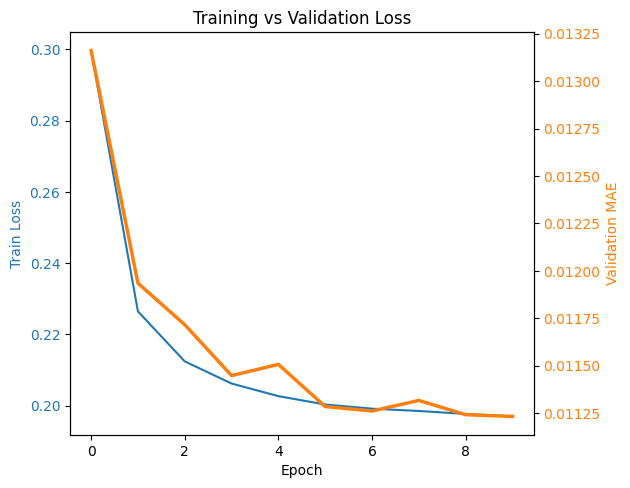

--- STGCN TRAINING COMPLETE ---


In [40]:
# Clear previous results file if it exists
results_file = 'models/saved/comparison_results.txt'
if os.path.exists(results_file):
    os.remove(results_file)
    print("Removed old results file.")

# Set arguments for STGCN training
args_stgcn = argparse.Namespace(
    model_name='STGCN',
    data_dir='data/processed',
    save_dir='models/saved',
    epochs=10,
    batch_size=32,
    learning_rate=0.001
)

print("--- STARTING STGCN TRAINING ---")
run_model_training(args_stgcn)
print("--- STGCN TRAINING COMPLETE ---")

--- STARTING ASTGCN TRAINING ---
Using device: cuda
Loading data...
Data loaded.
Model Config: Nodes=307, InFeat=1, SeqLen=12, PredLen=12
Model ASTGCN initialized.
Starting training...
Epoch 1/10 | Time: 8.38s | Train Loss: 0.3049 | Val MAE: 0.0134 | Val RMSE: 0.0277
Model saved to models/saved/ASTGCN_best.pth
Epoch 2/10 | Time: 8.31s | Train Loss: 0.2252 | Val MAE: 0.0116 | Val RMSE: 0.0270
Model saved to models/saved/ASTGCN_best.pth
Epoch 3/10 | Time: 8.33s | Train Loss: 0.2134 | Val MAE: 0.0111 | Val RMSE: 0.0266
Model saved to models/saved/ASTGCN_best.pth
Epoch 4/10 | Time: 8.33s | Train Loss: 0.2005 | Val MAE: 0.0110 | Val RMSE: 0.0264
Model saved to models/saved/ASTGCN_best.pth
Epoch 5/10 | Time: 8.31s | Train Loss: 0.1918 | Val MAE: 0.0107 | Val RMSE: 0.0263
Model saved to models/saved/ASTGCN_best.pth
Epoch 6/10 | Time: 8.32s | Train Loss: 0.1895 | Val MAE: 0.0106 | Val RMSE: 0.0262
Model saved to models/saved/ASTGCN_best.pth
Epoch 7/10 | Time: 8.30s | Train Loss: 0.1876 | Val M

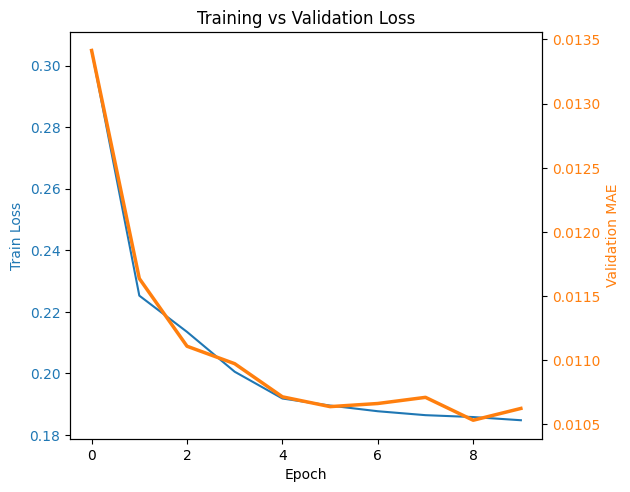

--- ASTGCN TRAINING COMPLETE ---


In [41]:
# Set arguments for ASTGCN training
args_astgcn = argparse.Namespace(
    model_name='ASTGCN',
    data_dir='data/processed',
    save_dir='models/saved',
    epochs=10,
    batch_size=32,
    learning_rate=0.001
)

print("--- STARTING ASTGCN TRAINING ---")
run_model_training(args_astgcn)
print("--- ASTGCN TRAINING COMPLETE ---")

In [42]:
results_file = 'models/saved/comparison_results.txt'
if os.path.exists(results_file):
    with open(results_file, 'r') as f:
        print("--- FINAL COMPARISON RESULTS ---")
        print(f.read())
else:
    print("Results file not found. Please run the training cells first.")

--- FINAL COMPARISON RESULTS ---
Model: STGCN
Test MAE: 0.0097
Test RMSE: 0.0233
--------------------
Model: ASTGCN
Test MAE: 0.0091
Test RMSE: 0.0227
--------------------



#Model Visualization

Loading test data and scaler...

--- Visualizing STGCN ---


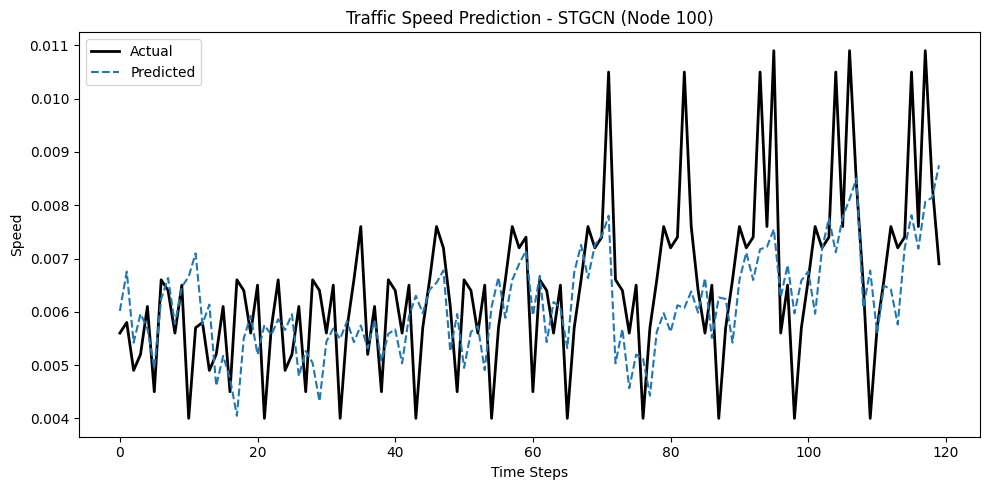

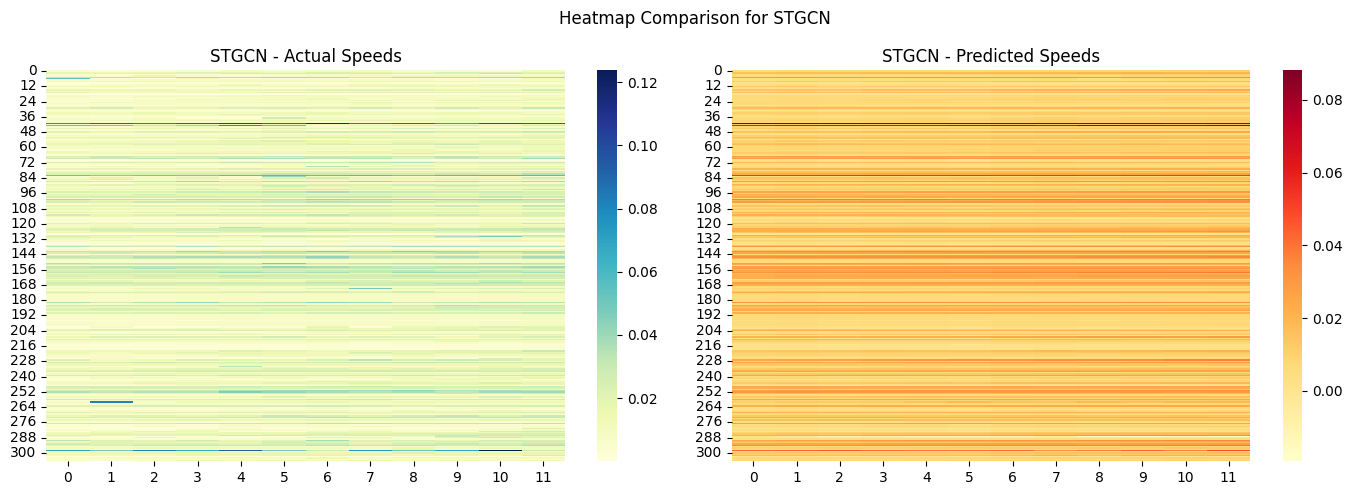

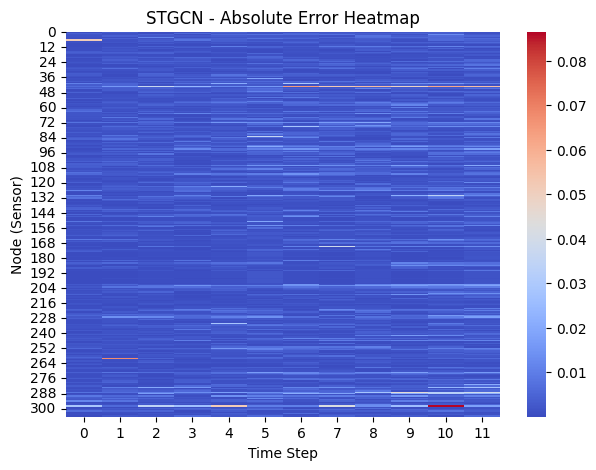

STGCN → MAE: 0.0033, RMSE: 0.0056

--- Visualizing ASTGCN ---


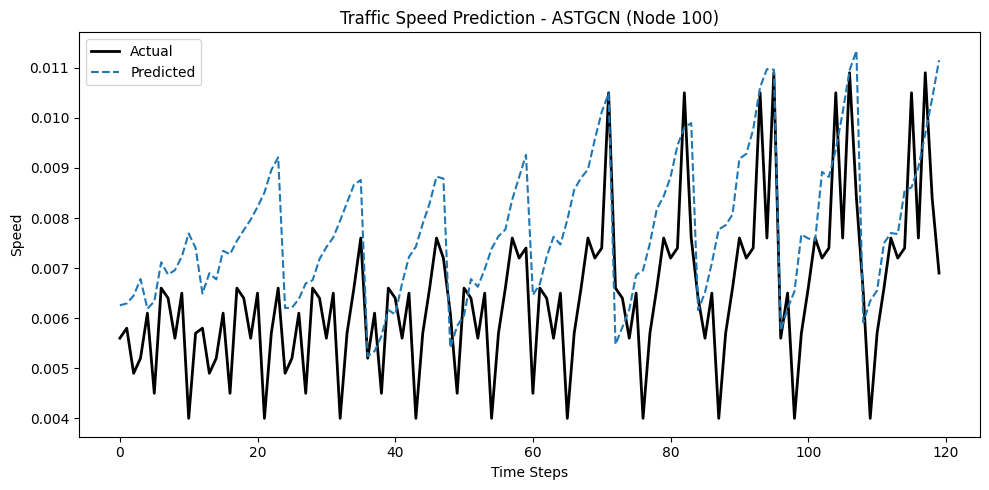

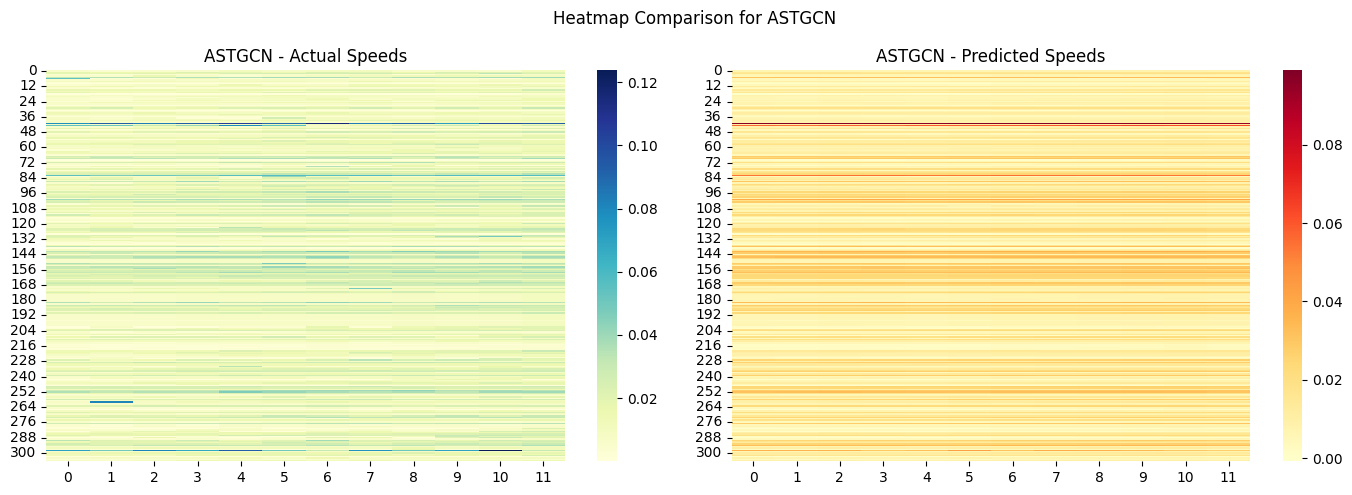

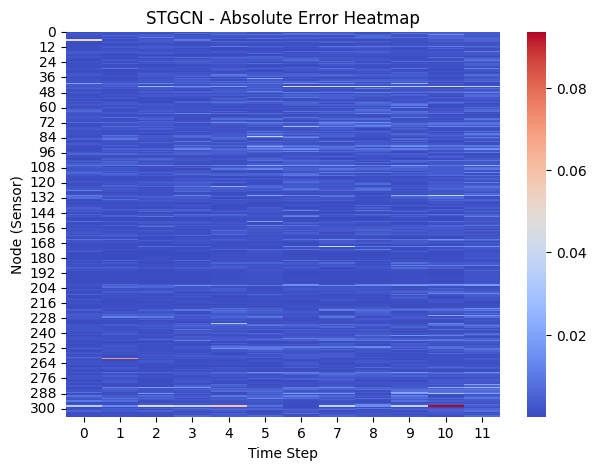

ASTGCN → MAE: 0.0031, RMSE: 0.0054


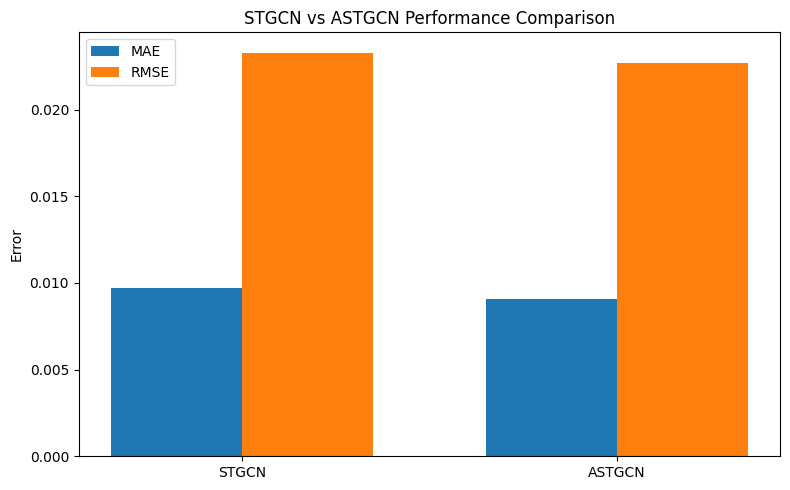

In [43]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# from project import STGCN, ASTGCN, load_dataset, load_adjacency_matrix, load_scaler, masked_mae, masked_rmse

# -----------------------------
# CONFIGURATION
# -----------------------------
DATA_DIR = "data/processed"
SAVE_DIR = "models/saved"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NODE_ID = 100     # Change this to visualize another sensor
NUM_SAMPLES = 10  # Number of test samples to visualize
MODELS = ["STGCN", "ASTGCN"]

# -----------------------------
# LOAD DATA & SCALER
# -----------------------------
print("Loading test data and scaler...")
dataloaders = load_dataset(DATA_DIR, batch_size=32, device=DEVICE)
test_loader = dataloaders["test"]
scaler = load_scaler(DATA_DIR)
adj_matrix = load_adjacency_matrix(DATA_DIR, DEVICE)

x_test, y_true = next(iter(test_loader))
x_test, y_true = x_test.to(DEVICE), y_true.to(DEVICE)

# -----------------------------
# VISUALIZATION LOOP
# -----------------------------
for model_name in MODELS:
    print(f"\n--- Visualizing {model_name} ---")

    # Load model
    if model_name == "STGCN":
        model = STGCN(
            num_nodes=x_test.shape[2],
            in_features=x_test.shape[3],
            seq_len=x_test.shape[1],
            pred_len=y_true.shape[1]
        )
    else:
        model = ASTGCN(
            num_nodes=x_test.shape[2],
            in_features=x_test.shape[3],
            seq_len=x_test.shape[1],
            pred_len=y_true.shape[1]
        )

    model_path = os.path.join(SAVE_DIR, f"{model_name}_best.pth")
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()

    with torch.no_grad():
        preds = model(x_test[:NUM_SAMPLES], adj_matrix).cpu().numpy()
        true = y_true[:NUM_SAMPLES].cpu().numpy()

    # Inverse scale predictions
    preds_inv = scaler.inverse_transform(preds.reshape(-1, 1)).reshape(preds.shape)
    true_inv = scaler.inverse_transform(true.reshape(-1, 1)).reshape(true.shape)

    # -----------------------------
    # 1️⃣ Line Plot - Predicted vs Actual for One Node
    # -----------------------------
    plt.figure(figsize=(10, 5))
    plt.plot(true_inv[:, :, NODE_ID, 0].flatten(), label="Actual", color="black", linewidth=2)
    plt.plot(preds_inv[:, :, NODE_ID, 0].flatten(), label="Predicted", linestyle="--")
    plt.title(f"Traffic Speed Prediction - {model_name} (Node {NODE_ID})")
    plt.xlabel("Time Steps")
    plt.ylabel("Speed")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/{model_name}_node_{NODE_ID}_prediction.png")
    plt.show()

    # -----------------------------
    # 2️⃣ Heatmap - Actual vs Predicted
    # -----------------------------
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(true_inv[0, :, :, 0].T, ax=axes[0], cmap="YlGnBu")
    axes[0].set_title(f"{model_name} - Actual Speeds")

    sns.heatmap(preds_inv[0, :, :, 0].T, ax=axes[1], cmap="YlOrRd")
    axes[1].set_title(f"{model_name} - Predicted Speeds")

    plt.suptitle(f"Heatmap Comparison for {model_name}")
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/{model_name}_heatmap.png")
    plt.show()

    error_map = np.abs(preds_inv[0, :, :, 0] - true_inv[0, :, :, 0])
    plt.figure(figsize=(7, 5))
    sns.heatmap(error_map.T, cmap="coolwarm")
    plt.title("STGCN - Absolute Error Heatmap")
    plt.xlabel("Time Step")
    plt.ylabel("Node (Sensor)")
    plt.show()

    # -----------------------------
    # 3️⃣ Compute & Print MAE/RMSE
    # -----------------------------
    y_pred_tensor = torch.tensor(preds_inv)
    y_true_tensor = torch.tensor(true_inv)
    mae = masked_mae(y_pred_tensor, y_true_tensor).item()
    rmse = masked_rmse(y_pred_tensor, y_true_tensor).item()
    print(f"{model_name} → MAE: {mae:.4f}, RMSE: {rmse:.4f}")



# -----------------------------
# 4️⃣ Bar Chart - Model Comparison (Fixed)
# -----------------------------
results_path = os.path.join(SAVE_DIR, "comparison_results.txt")

# Read metrics safely
model_metrics = {}
with open(results_path, "r") as f:
    lines = [line.strip() for line in f.readlines()]
    for i in range(len(lines)):
        if lines[i].startswith("Model:"):
            model_name = lines[i].split(":")[1].strip()
            mae = float(lines[i+1].split(":")[1])
            rmse = float(lines[i+2].split(":")[1])
            model_metrics[model_name] = (mae, rmse)

# Extract in correct order
mae_values = [model_metrics[m][0] for m in MODELS if m in model_metrics]
rmse_values = [model_metrics[m][1] for m in MODELS if m in model_metrics]

x = np.arange(len(MODELS))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, mae_values, width, label="MAE")
plt.bar(x + width/2, rmse_values, width, label="RMSE")
plt.xticks(x, MODELS)
plt.ylabel("Error")
plt.title("STGCN vs ASTGCN Performance Comparison")
plt.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/comparison_bar_chart.png")
plt.show()

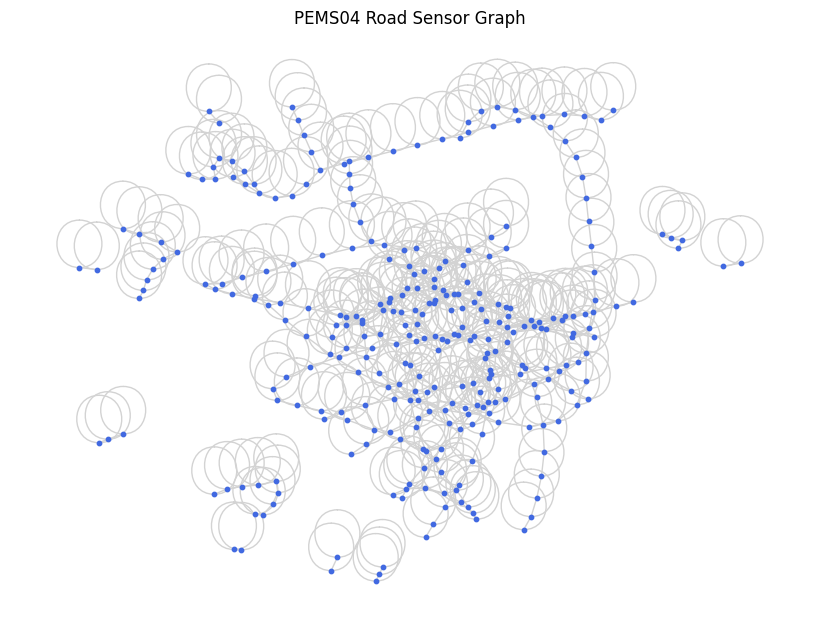

In [44]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

adj_data = np.load("data/processed/graph_data.npz")
adj_matrix = adj_data["adj_matrix"]

G = nx.from_numpy_array(adj_matrix)
plt.figure(figsize=(8, 6))
nx.draw(G, node_size=10, node_color="royalblue", edge_color="lightgray")
plt.title("PEMS04 Road Sensor Graph")
plt.show()


#Model Visualization Explanation

**Traffic Speed Prediction – STGCN (Node 100)**  

The plot compares the **actual** and **predicted** traffic speeds over 120 time steps (≈ 10 hours).  

The **black solid line** represents the **true observed speeds** from the test dataset.  
The **blue dashed line** shows the **STGCN model’s predictions**.  

The model successfully follows the **overall upward trend** in traffic speed and captures several **local fluctuations**, demonstrating that it has learned meaningful **temporal dependencies**. However, the predicted curve is slightly smoother than the actual values, indicating that **STGCN underestimates sharp variations or peaks**—a typical behavior for convolution-based spatio-temporal models that average across neighboring nodes and time steps.


------------------------------------------------------------------

**Heatmap Comparison for STGCN (Actual vs Predicted Speeds)**  

The heatmaps illustrate the spatio-temporal distribution of traffic speeds across all sensors (y-axis) and time steps (x-axis) for a selected test batch.  
The **left heatmap** shows the actual observed speeds, while the **right heatmap** represents the STGCN model’s predictions.  

Both heatmaps exhibit consistent spatial patterns, indicating that STGCN effectively captures the overall network-wide traffic flow structure. However, the predicted map appears smoother, suggesting that the model slightly underestimates sudden variations or local fluctuations in speed—an expected behavior of convolution-based models that aggregate information across neighboring nodes.


---------------------------------------------------------------

**STGCN – Absolute Error Heatmap**  

This heatmap visualizes the absolute prediction error for each sensor (y-axis) across the forecast horizon (x-axis).  
Most regions appear dark blue, indicating **low prediction error** across both spatial and temporal dimensions.  
A few isolated red patches correspond to **localized time intervals or sensors** where the model deviated from actual values—typically occurring during abrupt traffic changes or anomalies.  

Overall, the STGCN demonstrates strong spatio-temporal generalization with minimal localized errors.


------------------------------------------------------------------

**Traffic Speed Prediction – ASTGCN (Node 100)**  

This plot compares the **actual** and **predicted** traffic speeds for Node 100 over 120 time steps (≈ 10 hours).  
The **black solid line** shows the true observed speeds, while the **blue dashed line** represents the predictions from the ASTGCN model.  

Compared to STGCN, the ASTGCN model more closely follows the sharp fluctuations and short-term variations in traffic speeds.  
This improvement highlights the benefit of incorporating **spatial and temporal attention mechanisms**, which allow the model to dynamically focus on the most relevant nodes and time intervals, leading to higher prediction fidelity.


---------------------------------------------------------------

**Heatmap Comparison for ASTGCN (Actual vs Predicted Speeds)**  

The heatmaps display the spatio-temporal distribution of actual (left) and predicted (right) traffic speeds across all sensors and time steps.  
The overall structural similarity between the two heatmaps indicates that ASTGCN effectively captures the global spatial dependencies across the sensor network.  

Compared to STGCN, the ASTGCN’s predicted map shows finer local variations and higher contrast, suggesting that the **attention mechanism enables better modeling of localized traffic changes** without over-smoothing the predictions.


----------------------------------------------------------------

**ASTGCN – Absolute Error Heatmap**  

This figure shows the **absolute prediction error** for each sensor across the forecast horizon.  
Most regions remain dark blue, indicating low overall prediction error, while occasional light red streaks correspond to localized spikes in error at specific sensors or time steps.  

The distribution of errors is more uniform and less intense compared to STGCN, confirming that **ASTGCN achieves more accurate and stable spatio-temporal predictions** by adaptively weighting critical nodes and time frames.


---------------------------------------------------------------

**PEMS04 Road Sensor Graph**  

The graph visualizes the spatial connectivity of the **PEMS04 traffic sensor network**, where each **blue node** represents a road sensor and each **gray edge** denotes a direct road connection between sensors, as defined in the adjacency matrix.  

The central dense cluster corresponds to **urban regions or major highways** with high sensor density and strong spatial interconnections, while the smaller, peripheral clusters represent **isolated road segments or ramps** with limited connectivity.  

This visualization highlights the **non-Euclidean spatial structure** of the dataset, justifying the use of **graph-based neural networks (STGCN and ASTGCN)** to model traffic flow dynamics across the network.


#DataSet Visualization

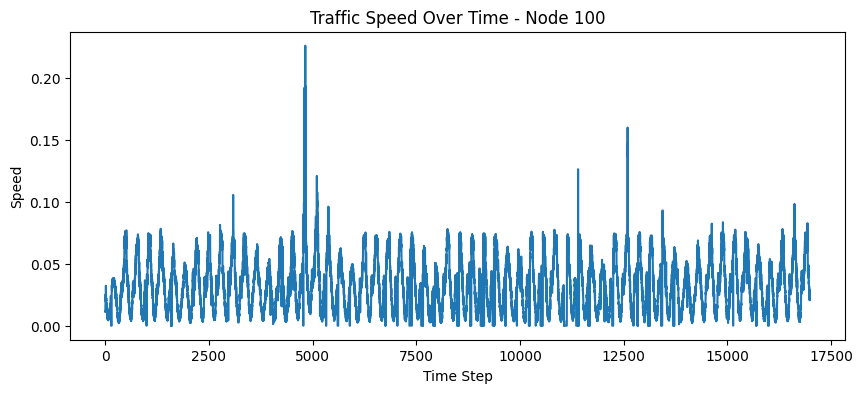

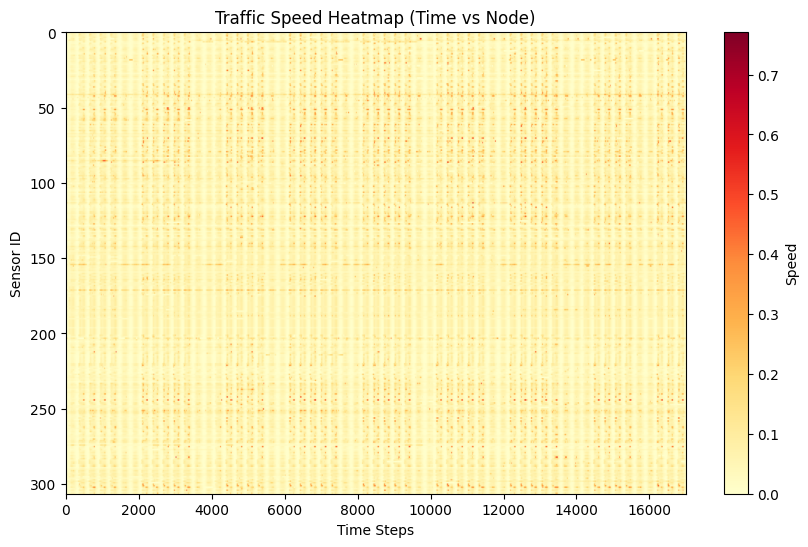

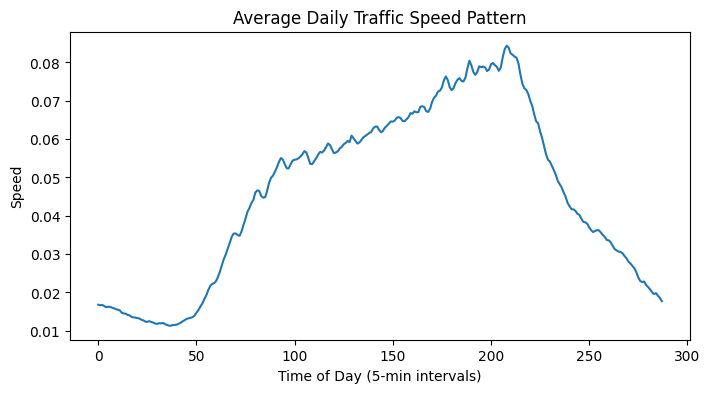

In [45]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("data/PEMS04.npz")["data"]
node_id = 100  # example sensor
plt.figure(figsize=(10,4))
plt.plot(data[:, node_id, 1])  # assuming index 1 = speed
plt.title(f"Traffic Speed Over Time - Node {node_id}")
plt.xlabel("Time Step")
plt.ylabel("Speed")
plt.show()

speed_data = data[:, :, 1]  # (time, nodes)
plt.figure(figsize=(10,6))
plt.imshow(speed_data.T, aspect="auto", cmap="YlOrRd")
plt.title("Traffic Speed Heatmap (Time vs Node)")
plt.xlabel("Time Steps")
plt.ylabel("Sensor ID")
plt.colorbar(label="Speed")
plt.show()

samples_per_day = 288  # 5-min intervals per day
mean_speed = speed_data[:samples_per_day*7].reshape(7, samples_per_day, -1).mean(axis=(0,2))
plt.figure(figsize=(8,4))
plt.plot(mean_speed)
plt.title("Average Daily Traffic Speed Pattern")
plt.xlabel("Time of Day (5-min intervals)")
plt.ylabel("Speed")
plt.show()


#Dataset Visualization Explanation

**Traffic Speed Over Time – Node 100**  

This plot shows the variation in **traffic speed for a single sensor (Node 100)** across the entire time horizon of the dataset.  
Each point represents the average speed recorded every 5 minutes. The plot exhibits strong **periodic patterns**, indicating daily cycles of traffic flow with repeated peaks and troughs.  
The sharp spikes represent sudden increases in speed (possibly during off-peak hours or low congestion), while the denser wave-like regions correspond to regular traffic rush hours.  
This confirms the presence of **temporal periodicity**, motivating the use of models that can learn time-dependent patterns such as STGCN and ASTGCN.


--------------------------------------------------------------

**Traffic Speed Heatmap (Time vs Node)**  

The heatmap illustrates the **spatio-temporal variation** of traffic speed across all sensors (y-axis) and time steps (x-axis).  
Lighter regions indicate higher speeds, while darker areas represent congestion or low-speed conditions.  
The vertical periodic streaks reflect daily fluctuations that occur simultaneously across multiple sensors, showing that traffic congestion patterns are **highly correlated spatially**.  
This visualization demonstrates the **spatial dependency** inherent in traffic data—traffic flow at one location is influenced by conditions at nearby locations.


---------------------------------------------------------------

**Average Daily Traffic Speed Pattern**  

This figure shows the **average daily trend** in traffic speed, computed by averaging over multiple days.  
The clear **diurnal pattern** reveals two major transitions:  
- A steady rise in the morning (corresponding to increased movement during morning hours).  
- A gradual decline later in the day, likely representing evening congestion and reduced nighttime traffic.  

This cyclical behavior confirms the **temporal regularity** of traffic data and underscores the importance of incorporating temporal modeling in predictive frameworks.
